In [20]:
import pandas as pd
titanic = pd.read_csv("https://peter.butka.website.tuke.sk/test/titanic2.csv")
titanic.head()

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family,has_family,fare_ordinal,title,title_short,age_ordinal,deck
0,1,1,female,29.00,0,0,24160,211.3375,B5,Southampton,0,False,most expensive,Miss,Miss,adult,B
1,1,1,male,0.92,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Master,rare title,child,C
2,1,0,female,2.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Miss,Miss,child,C
3,1,0,male,30.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mr,Mr,adult,C
4,1,0,female,25.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mrs,Mrs,adult,C


<AxesSubplot:xlabel='survived', ylabel='Count'>

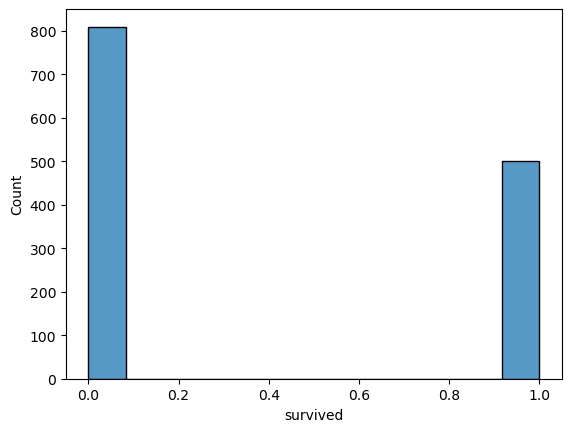

In [21]:
import seaborn as sns
sns.histplot(data=titanic, x="survived")

In [22]:
titanic['dAge'] = pd.cut(titanic['age'], bins=[0, 18, 100], labels=['child', 'adult'])

In [23]:
train_data = titanic.sample(frac=0.8)
test_data = titanic.drop(train_data.index)

In [30]:
type_unique = pd.unique(train_data.sex)
train_data["sex"] = train_data.apply(lambda row: 0 if row["sex"] == type_unique[0] else 1 , axis=1)
test_data["sex"] = test_data.apply(lambda row: 0 if row["sex"] == type_unique[0] else 1 , axis=1)

type_unique2 = pd.unique(train_data.dAge)
train_data["dAge"] = train_data.apply(lambda row: 0 if row["dAge"] == type_unique2[0] else 1 , axis=1)
test_data["dAge"] = test_data.apply(lambda row: 0 if row["dAge"] == type_unique2[0] else 1 , axis=1)

In [31]:
from sklearn.tree import DecisionTreeClassifier
X_train = train_data[['pclass', 'sex', 'dAge', 'fare']]
y_train = train_data['survived']
model = DecisionTreeClassifier()
model.fit(X_train, y_train)


DecisionTreeClassifier()

[Text(0.6167684785017731, 0.975, 'X[1] <= 0.5\ngini = 0.473\nsamples = 1047\nvalue = [645, 402]'),
 Text(0.3838098404255319, 0.925, 'X[3] <= 26.269\ngini = 0.305\nsamples = 675\nvalue = [548, 127]'),
 Text(0.16888297872340424, 0.875, 'X[3] <= 7.91\ngini = 0.236\nsamples = 490\nvalue = [423, 67]'),
 Text(0.07092198581560284, 0.825, 'X[3] <= 7.825\ngini = 0.185\nsamples = 203\nvalue = [182, 21]'),
 Text(0.0425531914893617, 0.775, 'X[3] <= 7.785\ngini = 0.232\nsamples = 142\nvalue = [123, 19]'),
 Text(0.028368794326241134, 0.725, 'X[0] <= 2.5\ngini = 0.199\nsamples = 134\nvalue = [119, 15]'),
 Text(0.02127659574468085, 0.675, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.03546099290780142, 0.675, 'X[3] <= 2.006\ngini = 0.213\nsamples = 124\nvalue = [109, 15]'),
 Text(0.028368794326241134, 0.625, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.0425531914893617, 0.625, 'X[3] <= 6.962\ngini = 0.203\nsamples = 122\nvalue = [108, 14]'),
 Text(0.03546099290780142, 0.575, 'gini = 0.0

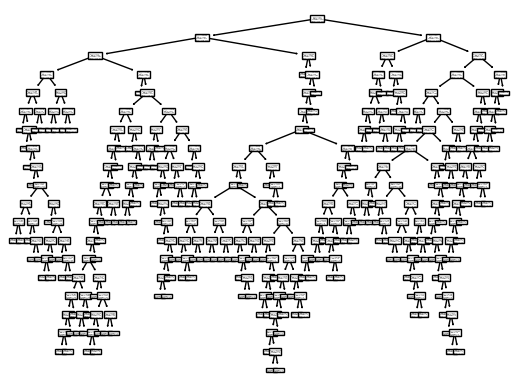

In [33]:
from sklearn.tree import plot_tree
plot_tree(model)

In [34]:
testPred_tree = model.predict(test_data[['pclass', 'sex', 'dAge', 'fare']])

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix
tbl = pd.crosstab(test_data['survived'], testPred_tree)
tbl

col_0,0,1
survived,,
0,145,19
1,39,59


In [36]:
from sklearn.metrics import classification_report
print(classification_report(test_data[['survived']], testPred_tree))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       164
           1       0.76      0.60      0.67        98

    accuracy                           0.78       262
   macro avg       0.77      0.74      0.75       262
weighted avg       0.78      0.78      0.77       262

